In [1]:
pip install opencv-python numpy matplotlib 'numpy<2'

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import copy

In [3]:
def add_gaussian_noise(image, mean=0, std=1):
    gaussian_noise = np.random.normal(mean, std, image.shape)
    noisy_image = image + gaussian_noise
    return np.clip(noisy_image, 0, 255).astype(image.dtype)

In [4]:
def add_rayleigh_noise(image, scale=1):
    rayleigh_noise = np.random.rayleigh(scale, image.shape)
    noisy_image = image + rayleigh_noise
    return np.clip(noisy_image, 0, 255).astype(image.dtype)

In [5]:
def add_exponential_noise(image, scale=1):
    exponential_noise = np.random.exponential(scale, image.shape)
    noisy_image = image + exponential_noise
    return np.clip(noisy_image, 0, 255).astype(image.dtype)

In [6]:
def add_salt_pepper_noise(image, salt_prob=0.05, pepper_prob=0.05):
    noisy = image.copy()

    num_salt = int(np.ceil(salt_prob * image.size))
    if num_salt > 0:
        coords = [np.random.randint(0, i-1, num_salt) for i in image.shape]
        noisy[coords[0], coords[1]] = 255

    num_pepper = int(np.ceil(pepper_prob * image.size))
    if num_pepper > 0:
        coords = [np.random.randint(0, i-1, num_pepper) for i in image.shape]
        noisy[coords[0], coords[1]] = 0
    return noisy

In [7]:
def add_uniform_noise(image, low=0, high=10):
    noise = np.random.uniform(low, high, image.shape)
    return np.clip(image + noise, 0, 255).astype(image.dtype)

In [8]:
def apply_box(image_input, box_kernel, filt_size):  # completed version of the one given in lab
    pad_size = int(np.floor(filt_size / 2))
    image_padded = np.pad(image_input, ((pad_size, pad_size), (pad_size, pad_size)), mode='symmetric')
    image_box = np.copy(image_input).astype(float)
    rows, cols = image_input.shape
    for i in range(rows):
        for j in range(cols):
            patch = image_padded[i:i+filt_size, j:j+filt_size]
            image_box[i, j] = np.sum(box_kernel * patch)
    return np.clip(image_box, 0, 255).astype(np.uint8)

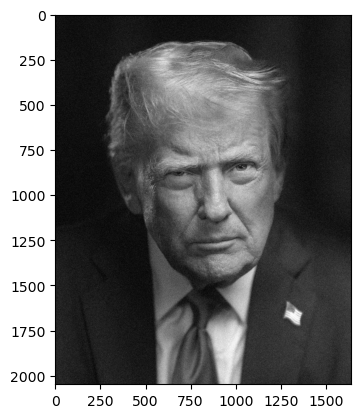

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import copy

image = cv2.imread('trump.jpg', cv2.IMREAD_GRAYSCALE)  

noisy_image = add_gaussian_noise(image, mean=10,std=20)
plt.imshow(noisy_image, cmap='gray')
plt.show() 

In [ ]:
def apply_geometric_mean(image_input, filt_size):
    pad = filt_size // 2
    padded = np.pad(image_input, ((pad, pad), (pad, pad)), mode='symmetric')
    out = np.zeros_like(image_input, dtype=float)
    for i in range(image_input.shape[0]):
        for j in range(image_input.shape[1]):
            patch = padded[i:i+filt_size, j:j+filt_size].astype(float)
            patch = np.maximum(patch, 1e-10)
            out[i,j] = np.exp(np.mean(np.log(patch)))
    return np.clip(out, 0, 255).astype(np.uint8)

def apply_harmonic_mean(image_input, filt_size):
    pad = filt_size // 2
    padded = np.pad(image_input, ((pad, pad), (pad, pad)), mode='symmetric')
    out = np.zeros_like(image_input, dtype=float)
    for i in range(image_input.shape[0]):
        for j in range(image_input.shape[1]):
            patch = padded[i:i+filt_size, j:j+filt_size].astype(float)
            patch = np.maximum(patch, 1e-10)
            out[i,j] = (filt_size**2) / np.sum(1/patch)
    return np.clip(out, 0, 255).astype(np.uint8)

def apply_contraharmonic_mean(image_input, filt_size, Q=0):
    pad = filt_size // 2
    padded = np.pad(image_input, ((pad, pad), (pad, pad)), mode='symmetric')
    out = np.zeros_like(image_input, dtype=float)
    for i in range(image_input.shape[0]):
        for j in range(image_input.shape[1]):
            patch = padded[i:i+filt_size, j:j+filt_size].astype(float)
            out[i,j] = np.sum(patch**(Q+1)) / np.sum(patch**Q) if np.sum(patch**Q) != 0 else 0
    return np.clip(out, 0, 255).astype(np.uint8)

def apply_median_filter(image_input, filt_size):
    pad = filt_size // 2
    padded = np.pad(image_input, ((pad, pad), (pad, pad)), mode='symmetric')
    out = np.zeros_like(image_input, dtype=float)
    for i in range(image_input.shape[0]):
        for j in range(image_input.shape[1]):
            out[i,j] = np.median(padded[i:i+filt_size, j:j+filt_size])
    return np.clip(out, 0, 255).astype(np.uint8)

def apply_max_filter(image_input, filt_size):
    pad = filt_size // 2
    padded = np.pad(image_input, ((pad, pad), (pad, pad)), mode='symmetric')
    out = np.zeros_like(image_input, dtype=float)
    for i in range(image_input.shape[0]):
        for j in range(image_input.shape[1]):
            out[i,j] = np.max(padded[i:i+filt_size, j:j+filt_size])
    return np.clip(out, 0, 255).astype(np.uint8)

def apply_min_filter(image_input, filt_size):
    pad = filt_size // 2
    padded = np.pad(image_input, ((pad, pad), (pad, pad)), mode='symmetric')
    out = np.zeros_like(image_input, dtype=float)
    for i in range(image_input.shape[0]):
        for j in range(image_input.shape[1]):
            out[i,j] = np.min(padded[i:i+filt_size, j:j+filt_size])
    return np.clip(out, 0, 255).astype(np.uint8)

def apply_midpoint_filter(image_input, filt_size):
    pad = filt_size // 2
    padded = np.pad(image_input, ((pad, pad), (pad, pad)), mode='symmetric')
    out = np.zeros_like(image_input, dtype=float)
    for i in range(image_input.shape[0]):
        for j in range(image_input.shape[1]):
            patch = padded[i:i+filt_size, j:j+filt_size]
            out[i,j] = (np.max(patch) + np.min(patch)) / 2
    return np.clip(out, 0, 255).astype(np.uint8)

def apply_alpha_trimmed_mean(image_input, filt_size, d):
    if d % 2 != 0: d += 1
    trim = d // 2
    pad = filt_size // 2
    padded = np.pad(image_input, ((pad, pad), (pad, pad)), mode='symmetric')
    out = np.zeros_like(image_input, dtype=float)
    for i in range(image_input.shape[0]):
        for j in range(image_input.shape[1]):
            patch = np.sort(padded[i:i+filt_size, j:j+filt_size].flatten().astype(float))
            trimmed = patch[trim:-trim] if len(patch) > d else patch
            out[i,j] = np.mean(trimmed)
    return np.clip(out, 0, 255).astype(np.uint8)

In [ ]:
for mean, std in [(0,5),(0,10),(5,10),(0,20),(10,30)]:
    noisy = add_gaussian_noise(image, mean, std)
    plt.figure()
    plt.subplot(1,2,1); plt.imshow(noisy, cmap='gray'); plt.title(f'Gaussian m={mean} std={std}')
    plt.subplot(1,2,2); plt.hist(noisy.ravel(), 256, [0,255]); plt.title('Histogram')
    plt.savefig(f'gaussian_m{mean}_std{std}.png')
    plt.close()

for s,p in [(0.01,0.01),(0.05,0.05),(0.1,0.1),(0.05,0.01),(0.01,0.05)]:
    noisy = add_salt_pepper_noise(image, s, p)
    plt.figure()
    plt.subplot(1,2,1); plt.imshow(noisy, cmap='gray'); plt.title(f'S&P salt={s} pepper={p}')
    plt.subplot(1,2,2); plt.hist(noisy.ravel(), 256, [0,255])
    plt.savefig(f'sp_s{s}_p{p}.png')
    plt.close()

for lo,hi in [(0,5),(0,10),(5,15),(-5,5),(0,20)]:
    noisy = add_uniform_noise(image, lo, hi)
    plt.figure()
    plt.subplot(1,2,1); plt.imshow(noisy, cmap='gray'); plt.title(f'Uniform {lo}-{hi}')
    plt.subplot(1,2,2); plt.hist(noisy.ravel(), 256, [0,255])
    plt.savefig(f'uniform_{lo}_{hi}.png')
    plt.close()

In [ ]:
def denoise_and_save(noisy, filter_func, title, size=None, **kwargs):
    if size is None:
        filtered = filter_func(noisy, **kwargs)
    else:
        filtered = filter_func(noisy, size, **kwargs)
    plt.figure()
    plt.subplot(1,3,1); plt.imshow(image, cmap='gray'); plt.title('Original')
    plt.subplot(1,3,2); plt.imshow(noisy, cmap='gray'); plt.title('Noisy')
    plt.subplot(1,3,3); plt.imshow(filtered, cmap='gray'); plt.title(title)
    plt.savefig(f"{title.replace(' ','_').replace('=','')}.png")
    plt.close()
    return filtered

In [14]:
noisy_g = add_gaussian_noise(image, 0, 20)
denoise_and_save(noisy_g, apply_median_filter, "Median 3x3 on Gaussian", 3)

noisy_low = add_gaussian_noise(image, 0, np.sqrt(0.0009))
for s in [3,5]:
    denoise_and_save(noisy_low, apply_geometric_mean, f"Geometric {s}x{s}", s)
    denoise_and_save(noisy_low, lambda img: cv2.boxFilter(img, -1, (s,s)), f"Mean {s}x{s}", None)

noisy_high = add_gaussian_noise(image, 0, np.sqrt(0.09))
for s in [3,5,7]:
    denoise_and_save(noisy_high, apply_geometric_mean, f"Geometric {s}x{s} high var", s)

noisy_sp01 = add_salt_pepper_noise(image, 0.1, 0.1)
denoise_and_save(noisy_sp01, apply_median_filter, "Median 3x3 S&P 0.1", 3)

noisy_sp02 = add_salt_pepper_noise(image, 0.2, 0.2)
for s in [3,5,7]:
    denoise_and_save(noisy_sp02, apply_median_filter, f"Median {s}x{s} S&P 0.2", s)


noisy_gs = add_gaussian_noise(image, 0, np.sqrt(0.0009))
noisy_gs = add_salt_pepper_noise(noisy_gs, 0.1, 0)
denoise_and_save(noisy_gs, apply_harmonic_mean, "Harmonic 5x5 Gaussian+Salt", 5)
denoise_and_save(noisy_gs, apply_harmonic_mean, "Harmonic 7x7 Gaussian+Salt", 7)

for d in [4,6,8,10,12,14,16]:
    noisy_mix = add_gaussian_noise(image, 0, np.sqrt(0.009))
    noisy_mix = add_salt_pepper_noise(noisy_mix, 0.1, 0.1)
    denoise_and_save(noisy_mix, apply_alpha_trimmed_mean, f"Alpha-trimmed d={d} 7x7", 7, d=d)

NameError: name 'denoise_and_save' is not defined